# Benford's Law and Anomaly Detection

This project investigates whether Benford's Law and other statistical
methods can be used to identify unusual transactions in financial data.

The dataset used in this project is a synthetic financial ledger with
known, deliberately planted anomalies.

Because the anomalies are known in advance, the performance of each
detection method can later be evaluated against the true results.

## Executive Summary

This project explores rule-based anomaly screening and Benford's Law using a synthetic financial ledger containing 5,040 transactions and 130 deliberately planted anomalies across four categories: round-number amounts, transactions just below an approval threshold, duplicate payments, and fabricated amounts.

Three rule-based methods were evaluated individually and as a combined detector. On a newly generated synthetic ledger, the combined detector identified 100 of 130 planted anomalies, achieving 76.92% recall and 57.47% precision. It outperformed each individual rule in recall, but also flagged 74 clean transactions for further review.

Analysis by anomaly type revealed that the combined detector missed all 30 planted fabricated transactions because they did not trigger any of its three rules. This illustrates an important limitation of rule-based screening: methods designed to detect specific patterns may miss anomalies that do not match those patterns.

Benford's Law was also investigated as a group-level diagnostic. The clean transactions broadly followed the expected first-digit distribution, while the fabricated subset showed a substantially larger deviation. However, the fabricated amounts were deliberately generated using a different first-digit mechanism, and the subset was small.

The project demonstrates how mathematical and statistical methods can support transaction screening, how precision and recall quantify different aspects of detection performance, and why flagged transactions require further investigation. Because the data and anomaly mechanisms are synthetic, these findings do not establish performance on real financial records.


## Project Objective

The main objectives of this analysis are to:

1. Examine the distribution of transaction amounts.
2. Compare the first-digit distribution with Benford's Law.
3. Use statistical tests to measure how closely the data follows Benford's Law.
4. Identify potentially unusual transactions using several anomaly-detection methods.
5. Compare detected anomalies with the known planted anomalies.

In [1902]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

## 2. Load the Synthetic Ledger

The synthetic ledger was generated using `generate_ledger.py` and saved
as `data/synthetic_ledger.csv`.

We now load the CSV file into a pandas DataFrame for analysis.

In [1903]:
df = pd.read_csv("../data/synthetic_ledger.csv")

df.head()

,date,vendor,category,amount,is_anomaly,anomaly_type
0,2025-01-01,V008,Supplies,325.95,False,NaN
1,2025-01-01,V027,Maintenance,409.19,False,NaN
2,2025-01-01,V032,Travel,199.42,False,NaN
3,2025-01-01,V045,Maintenance,4092.81,False,NaN
4,2025-01-01,V038,Consulting,744.08,False,NaN


### Dataset Dimensions

First, we check the number of transactions and variables in the dataset.

In [1904]:
df.shape

(5040, 6)

### Dataset Columns

Next, we inspect the column names to understand what information is
available for each transaction.

In [1905]:
df.columns

Index(['date', 'vendor', 'category', 'amount', 'is_anomaly', 'anomaly_type'], dtype='str')

### Ground-Truth Anomalies

The synthetic dataset contains deliberately planted anomalies.

The `is_anomaly` and `anomaly_type` columns provide the ground truth.
This means we already know which transactions are anomalous.

This information will not be used to detect the anomalies. Instead, it
will be used later to evaluate how well our detection methods perform.

In [1906]:
df["anomaly_type"].replace("", "clean").value_counts()

anomaly_type
duplicate          40
fabricated         30
below_threshold    30
round_number       30
Name: count, dtype: int64

## 3. Inspecting Transaction Amounts

Before applying Benford's Law, we first examine the transaction
amounts that will be analysed.

In [1907]:
df["amount"].describe()

count      5040.000000
mean       2121.469052
std        7827.237112
min           3.340000
25%         240.320000
50%         643.215000
75%        1821.170000
max      336671.210000
Name: amount, dtype: float64

## 4. First-Digit Analysis

Benford's Law describes the expected distribution of the first digit
of numbers in many naturally occurring datasets.

For each transaction amount, we will extract its first digit.

For example:

- 1,234.50 → 1
- 582.20 → 5
- 73.10 → 7
- 9,876.00 → 9

The observed first-digit distribution will then be compared with the
theoretical Benford distribution.

In [1908]:
def first_digit(x):
    return int(f"{x:.2f}".lstrip("0.")[0])

### Extract the First Digit

We apply the first-digit function to every transaction amount and
store the result in a new column.

In [1909]:
df["first_digit"] = df["amount"].map(first_digit)

In [1910]:
df[["amount", "first_digit"]].head(10)

,amount,first_digit
0,325.95,3
1,409.19,4
2,199.42,1
3,4092.81,4
4,744.08,7
5,80.07,8
6,499.72,4
7,1994.09,1
8,1014.64,1
9,213.43,2


## 5. Observed First-Digit Distribution

We now count how frequently each first digit appears in the transaction
amounts. These frequencies represent the observed distribution in our
synthetic ledger.

In [1911]:
digits = np.arange(1, 10)

observed = (
    df["first_digit"]
    .value_counts(normalize=True)
    .reindex(digits, fill_value=0)
)

observed

first_digit
1    0.285317
2    0.165476
3    0.129960
4    0.110119
5    0.079365
6    0.068452
7    0.057937
8    0.055754
9    0.047619
Name: proportion, dtype: float64

## 6. Expected Benford Distribution

Benford's Law gives the theoretical probability that a number begins
with each digit from 1 to 9.

The probability is given by:

P(d) = log10(1 + 1/d)

where d is the first digit.

In [1912]:
expected = np.log10(1 + 1 / digits)

expected

array([0.30103   , 0.17609126, 0.12493874, 0.09691001, 0.07918125,
       0.06694679, 0.05799195, 0.05115252, 0.04575749])

## 7. Comparing Observed and Expected Distributions

We now compare the observed first-digit distribution of the ledger with
the theoretical distribution predicted by Benford's Law.

A visual comparison allows us to see which digits occur more or less
frequently than expected.

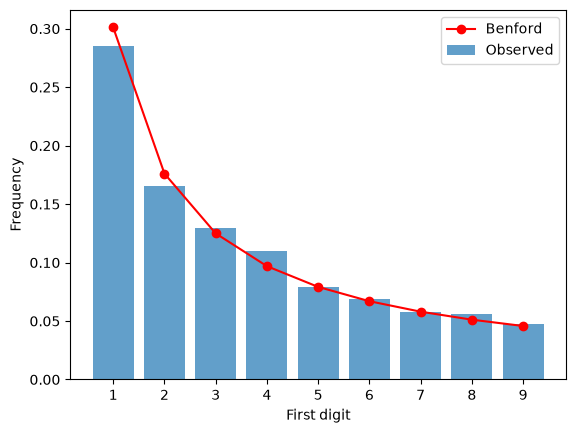

In [1913]:
plt.bar(digits, observed, alpha=0.7, label="Observed")
plt.plot(digits, expected, "ro-", label="Benford")

plt.xlabel("First digit")
plt.ylabel("Frequency")
plt.xticks(digits)
plt.legend()
plt.show()

## 8. Chi-Square Goodness-of-Fit Test

The visual comparison gives us an idea of how closely the observed
distribution follows Benford's Law.

The chi-square goodness-of-fit test provides a statistical way to
measure whether the difference between the observed and expected
distributions is large enough to be considered significant.

The null hypothesis is that the observed first-digit distribution
follows Benford's Law.

In [1914]:
n = len(df)

chi2, p = chisquare(
    observed * n,
    expected * n
)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p:.4f}")

Chi-square statistic: 20.09
p-value: 0.0100


## 9. Mean Absolute Deviation (MAD)

The Mean Absolute Deviation (MAD) measures the average absolute
difference between the observed first-digit proportions and the
proportions expected by Benford's Law.

A smaller MAD indicates that the observed distribution is closer to
Benford's Law.

In [1915]:
mad = np.abs(observed.values - expected).mean()

print(f"MAD: {mad:.4f}")

MAD: 0.0059


## 10. Benford Analysis of Clean Transactions

The dataset contains known planted anomalies. We now repeat the
Benford analysis using only transactions labelled as clean.

This allows us to compare the overall dataset with the underlying
clean transactions and examine whether the planted anomalies affected
the first-digit distribution.

In [1916]:
clean_df = df[df["is_anomaly"] == False].copy()

clean_df.shape

(4910, 7)

In [1917]:
clean_observed = (
    clean_df["first_digit"]
    .value_counts(normalize=True)
    .reindex(digits, fill_value=0)
)

clean_observed

first_digit
1    0.289002
2    0.164766
3    0.130754
4    0.105092
5    0.080652
6    0.068839
7    0.058656
8    0.054175
9    0.048065
Name: proportion, dtype: float64

### Clean Data: Chi-Square Test

We repeat the chi-square goodness-of-fit test using only the clean
transactions to determine whether their first-digit distribution
differs significantly from Benford's Law.

In [1918]:
clean_n = len(clean_df)

clean_chi2, clean_p = chisquare(
    clean_observed * clean_n,
    expected * clean_n
)

print(f"Clean-data chi-square statistic: {clean_chi2:.2f}")
print(f"Clean-data p-value: {clean_p:.4f}")

Clean-data chi-square statistic: 12.54
Clean-data p-value: 0.1287


### Clean Data: Mean Absolute Deviation

We also calculate the Mean Absolute Deviation for the clean
transactions so that we can compare the magnitude of the deviation
with the full dataset.

In [1919]:
clean_mad = np.abs(clean_observed.values - expected).mean()

print(f"Clean-data MAD: {clean_mad:.4f}")

Clean-data MAD: 0.0052


## 11. Detecting Suspiciously Round Amounts

A simple anomaly-detection approach is to identify transaction amounts
that are unusually round.

For example, payments of exactly 1,000, 3,000, or 10,000 may be worth
investigating because unusually round amounts can sometimes indicate
manual manipulation or fabricated transactions.

In this analysis, we use multiples of 1,000 as a screening rule.

This rule does not mean that every flagged transaction is anomalous.
Instead, it identifies transactions that can be investigated further.

In [1920]:
round_flags = df["amount"] % 1000 == 0

### Inspecting the Round-Number Flags

The screening rule produces a Boolean value for each transaction.
A value of `True` means that the transaction amount is an exact
multiple of 1,000, while `False` means that it is not.

In [1921]:
round_flags.head(20)

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
Name: amount, dtype: bool

### Counting the Flagged Transactions

We now count how many transactions were identified by the round-number
screening rule.

In [1922]:
round_flags.sum()

np.int64(30)

### Inspecting the Flagged Transactions

We now extract the transactions identified by the round-number screening
rule so that we can compare them with the known ground-truth labels.

In [1923]:
round_candidates = df[round_flags].copy()

round_candidates[
    ["date", "vendor", "category", "amount", "is_anomaly", "anomaly_type"]
]

,date,vendor,category,amount,is_anomaly,anomaly_type
289,2025-01-22,V011,Maintenance,1000.0,True,round_number
397,2025-01-31,V032,Consulting,2000.0,True,round_number
513,2025-02-07,V024,Consulting,3000.0,True,round_number
899,2025-03-06,V038,Supplies,8000.0,True,round_number
1097,2025-03-19,V024,Travel,3000.0,True,round_number
1342,2025-04-07,V015,Supplies,2000.0,True,round_number
1803,2025-05-09,V010,Utilities,3000.0,True,round_number
2021,2025-05-27,V031,Travel,2000.0,True,round_number
2071,2025-05-30,V047,Travel,10000.0,True,round_number
2096,2025-06-01,V047,Travel,2000.0,True,round_number


### Evaluating the Round-Number Detector

We now compare the transactions flagged by our rule with the known
ground-truth labels in the dataset.

This allows us to determine how many flagged transactions were actually
planted anomalies.

In [1924]:
round_candidates["anomaly_type"].replace("", "clean").value_counts()

anomaly_type
round_number    30
Name: count, dtype: int64

### Round-Number Detection Performance

The round-number rule flagged 30 transactions, and all 30 were known
round-number anomalies.

We can therefore calculate the true positives, false positives,
precision, and recall of this detection method.

In [1925]:
true_positives = (
    (round_candidates["is_anomaly"] == True) &
    (round_candidates["anomaly_type"] == "round_number")
).sum()

false_positives = (
    round_candidates["is_anomaly"] == False
).sum()

actual_round_anomalies = (
    (df["anomaly_type"] == "round_number")
).sum()

false_negatives = actual_round_anomalies - true_positives

precision = true_positives / (true_positives + false_positives)
recall = true_positives / (true_positives + false_negatives)

print(f"True positives: {true_positives}")
print(f"False positives: {false_positives}")
print(f"False negatives: {false_negatives}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

True positives: 30
False positives: 0
False negatives: 0
Precision: 100.00%
Recall: 100.00%


## 12. Detecting Transactions Just Below the Approval Limit

Financial organisations often have approval thresholds for transactions.

Transactions that repeatedly occur just below an approval limit may
warrant further investigation, as they could indicate attempts to avoid
additional levels of approval.

In our synthetic dataset, the approval limit is BND 5,000. We therefore
screen for transactions between 95% of the approval limit and the
approval limit itself.

This corresponds to transactions from BND 4,750 up to, but not
including, BND 5,000.

In [1926]:
approval_limit = 5000

below_threshold_flags = (
    (df["amount"] >= 0.95 * approval_limit) &
    (df["amount"] < approval_limit)
)

### Counting the Flagged Transactions

We now count how many transactions fall just below the BND 5,000
approval limit.

In [1927]:
below_threshold_flags.sum()

np.int64(57)

### Inspecting the Flagged Transactions

We now extract the transactions that fall just below the approval limit
and compare them with the known ground-truth labels.

In [1928]:
below_threshold_candidates = df[below_threshold_flags].copy()

below_threshold_candidates[
    ["date", "vendor", "category", "amount", "is_anomaly", "anomaly_type"]
]

,date,vendor,category,amount,is_anomaly,anomaly_type
146,2025-01-12,V047,Supplies,4877.82,True,below_threshold
243,2025-01-19,V002,Travel,4774.35,True,below_threshold
258,2025-01-20,V045,Consulting,4809.71,True,below_threshold
382,2025-01-30,V021,Utilities,4910.84,True,below_threshold
445,2025-02-04,V014,Supplies,4810.51,False,NaN
452,2025-02-04,V018,Supplies,4905.54,False,NaN
521,2025-02-08,V026,Utilities,4927.67,False,NaN
565,2025-02-11,V013,Utilities,4981.50,True,below_threshold
710,2025-02-21,V002,Maintenance,4963.27,False,NaN
716,2025-02-21,V024,Utilities,4773.62,True,below_threshold


### Evaluating the Below-Threshold Detector

We compare the transactions flagged by the approval-limit rule with
the known ground-truth labels.

This allows us to measure the detector's true positives, false
positives, false negatives, precision, and recall.

In [1929]:
true_positives = (
    (below_threshold_candidates["is_anomaly"] == True) &
    (below_threshold_candidates["anomaly_type"] == "below_threshold")
).sum()

false_positives = (
    below_threshold_candidates["is_anomaly"] == False
).sum()

actual_below_threshold = (
    df["anomaly_type"] == "below_threshold"
).sum()

false_negatives = actual_below_threshold - true_positives

precision = true_positives / (true_positives + false_positives)
recall = true_positives / (true_positives + false_negatives)

print(f"True positives: {true_positives}")
print(f"False positives: {false_positives}")
print(f"False negatives: {false_negatives}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

True positives: 30
False positives: 27
False negatives: 0
Precision: 52.63%
Recall: 100.00%


## 13. Detecting Potential Duplicate Payments

Duplicate payments can occur when the same transaction is recorded or
paid more than once.

To identify potential duplicates, we first look for transactions with
the same vendor, category, and amount.

Because the synthetic duplicate transactions may have dates shifted by
up to three days, the transaction date is not included in this initial
matching rule.

These matches will be treated as potential duplicates and evaluated
against the known ground-truth labels.

In [1930]:
duplicate_flags = df.duplicated(
    subset=["vendor", "category", "amount"],
    keep=False
)

### Counting Potential Duplicates

We now count the number of transactions that have a matching vendor,
category, and amount elsewhere in the ledger.

In [1931]:
duplicate_flags.sum()

np.int64(80)

### Inspecting Potential Duplicate Transactions

We now extract the transactions identified by the duplicate-detection
rule and compare them with the known ground-truth labels.

In [1932]:
duplicate_candidates = df[duplicate_flags].copy()

duplicate_candidates[
    ["date", "vendor", "category", "amount", "is_anomaly", "anomaly_type"]
].sort_values(
    ["vendor", "category", "amount", "date"]
)

,date,vendor,category,amount,is_anomaly,anomaly_type
170,2025-01-14,V001,Travel,701.38,False,NaN
198,2025-01-16,V001,Travel,701.38,True,duplicate
613,2025-02-14,V001,Utilities,610.26,True,duplicate
620,2025-02-14,V001,Utilities,610.26,False,NaN
4073,2025-10-22,V002,Supplies,122.91,False,NaN
...,...,...,...,...,...,...
3764,2025-10-01,V045,Maintenance,13061.61,True,duplicate
3957,2025-10-14,V047,Maintenance,4173.85,False,NaN
3966,2025-10-15,V047,Maintenance,4173.85,True,duplicate
351,2025-01-27,V050,Maintenance,45.02,False,NaN


### Ground-Truth Breakdown of Potential Duplicates

We now count the ground-truth labels among the transactions flagged as
potential duplicates.

This allows us to distinguish between the original transactions and
the deliberately planted duplicate transactions.

In [1933]:
duplicate_candidates["anomaly_type"].replace(
    "", "clean"
).value_counts()

anomaly_type
duplicate    40
Name: count, dtype: int64

### Evaluating the Duplicate Detection Rule

We now evaluate the duplicate detector against the ground-truth labels.

At the row level, a planted duplicate is treated as a true positive.
A clean transaction that was flagged is counted as a false positive.

This evaluation is useful, but it should be interpreted carefully because
the original transaction is naturally part of a duplicate pair.

In [1934]:
true_positives = (
    (duplicate_candidates["is_anomaly"] == True) &
    (duplicate_candidates["anomaly_type"] == "duplicate")
).sum()

false_positives = (
    duplicate_candidates["is_anomaly"] == False
).sum()

actual_duplicates = (
    df["anomaly_type"] == "duplicate"
).sum()

false_negatives = actual_duplicates - true_positives

precision = true_positives / (true_positives + false_positives)
recall = true_positives / (true_positives + false_negatives)

print(f"True positives: {true_positives}")
print(f"False positives: {false_positives}")
print(f"False negatives: {false_negatives}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

True positives: 40
False positives: 40
False negatives: 0
Precision: 50.00%
Recall: 100.00%


### Interpretation

The duplicate detector identified all 40 planted duplicate transactions,
giving a recall of 100%.

The row-level precision was 50% because the matching rule flags both
transactions in each duplicate pair. The 40 clean transactions are the
original transactions corresponding to the 40 planted duplicates.

Therefore, these should not be interpreted as ordinary false positives.
Instead, the detector is identifying potential duplicate pairs for
investigation.

This illustrates an important limitation of evaluating duplicate
detection using row-level classification alone. Pair-level evaluation
would provide a more appropriate measure of duplicate-detection
performance.

## 14. Statistical Outlier Detection

Business rules can identify specific types of suspicious transactions,
but they may miss transactions that are unusual for other reasons.

We therefore introduce statistical outlier detection.

A Z-score measures how far a value is from the mean in terms of standard
deviations.

A large absolute Z-score indicates that a transaction amount is
statistically unusual compared with the rest of the dataset.

In [1935]:
from scipy.stats import zscore

df["z_score"] = zscore(df["amount"])

df[["amount", "z_score"]].head(10)

,amount,z_score
0,325.95,-0.229416
1,409.19,-0.218781
2,199.42,-0.245583
3,4092.81,0.251882
4,744.08,-0.175991
5,80.07,-0.260833
6,499.72,-0.207214
7,1994.09,-0.016275
8,1014.64,-0.141421
9,213.43,-0.243793


### Examining the Most Extreme Z-Scores

Before choosing a threshold for statistical outliers, we examine the
transactions with the largest absolute Z-scores.

Using the absolute value allows us to identify transactions that are
unusually high or unusually low, regardless of direction.

In [1936]:
df["abs_z_score"] = df["z_score"].abs()

df[
    ["date", "vendor", "category", "amount", "z_score",
     "abs_z_score", "is_anomaly", "anomaly_type"]
].sort_values("abs_z_score", ascending=False).head(20)

,date,vendor,category,amount,z_score,abs_z_score,is_anomaly,anomaly_type
157,2025-01-13,V004,Travel,336671.21,42.745982,42.745982,False,NaN
2149,2025-06-04,V020,Travel,278935.56,35.369001,35.369001,False,NaN
3509,2025-09-13,V030,Utilities,115138.55,14.440382,14.440382,False,NaN
744,2025-02-23,V020,Supplies,84985.89,10.587726,10.587726,False,NaN
1300,2025-04-04,V012,Utilities,72349.18,8.973112,8.973112,False,NaN
2335,2025-06-16,V045,Supplies,71328.86,8.842744,8.842744,False,NaN
1032,2025-03-14,V019,Travel,65979.02,8.159186,8.159186,False,NaN
4202,2025-11-02,V034,Maintenance,64086.46,7.917371,7.917371,False,NaN
4952,2025-12-26,V009,Utilities,62614.84,7.729340,7.729340,False,NaN
2719,2025-07-13,V020,Consulting,56310.48,6.923821,6.923821,False,NaN


### Visualising the Z-Score Distribution

We now plot the distribution of Z-scores to see how transaction amounts
are distributed around the mean.

This will help us understand how unusual the extreme transactions are
and whether a simple Z-score threshold would be appropriate.

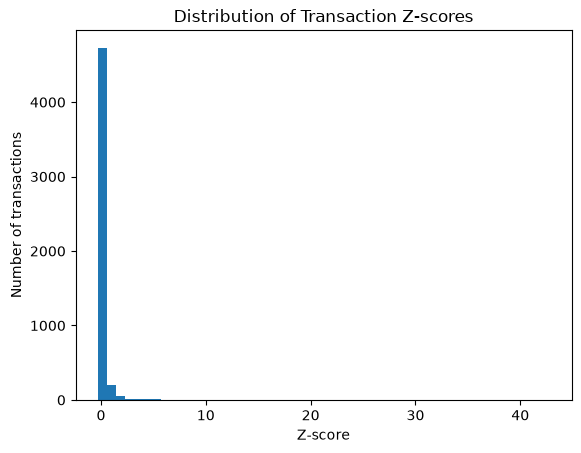

In [1937]:
plt.hist(df["z_score"], bins=50)

plt.xlabel("Z-score")
plt.ylabel("Number of transactions")
plt.title("Distribution of Transaction Z-scores")
plt.show()

### Applying a Z-Score Threshold

A common statistical screening rule is to flag observations with an
absolute Z-score greater than 3.

This means the transaction is more than three standard deviations away
from the mean.

We use this as a screening threshold rather than treating every flagged
transaction as an actual anomaly.

In [1938]:
z_flags = df["abs_z_score"] > 3

print(f"Transactions flagged: {z_flags.sum()}")

Transactions flagged: 37


### Inspecting Statistical Outliers

We now examine the transactions flagged by the Z-score rule and compare
them with the known ground-truth labels.

This allows us to determine which statistical outliers are planted
anomalies and which are legitimate but unusually large transactions.

In [1939]:
z_candidates = df[z_flags].copy()

z_candidates[
    ["date", "vendor", "category", "amount", "z_score",
     "is_anomaly", "anomaly_type"]
].sort_values("z_score", ascending=False)

,date,vendor,category,amount,z_score,is_anomaly,anomaly_type
157,2025-01-13,V004,Travel,336671.21,42.745982,False,NaN
2149,2025-06-04,V020,Travel,278935.56,35.369001,False,NaN
3509,2025-09-13,V030,Utilities,115138.55,14.440382,False,NaN
744,2025-02-23,V020,Supplies,84985.89,10.587726,False,NaN
1300,2025-04-04,V012,Utilities,72349.18,8.973112,False,NaN
2335,2025-06-16,V045,Supplies,71328.86,8.842744,False,NaN
1032,2025-03-14,V019,Travel,65979.02,8.159186,False,NaN
4202,2025-11-02,V034,Maintenance,64086.46,7.917371,False,NaN
4952,2025-12-26,V009,Utilities,62614.84,7.729340,False,NaN
2719,2025-07-13,V020,Consulting,56310.48,6.923821,False,NaN


### Evaluating the Z-Score Detector

We now compare the transactions flagged by the Z-score rule with the
known ground-truth anomalies.

This shows whether statistical extremeness alone is effective at
identifying the planted anomalies in our dataset.

In [1940]:
true_positives = (
    z_candidates["is_anomaly"] == True
).sum()

false_positives = (
    z_candidates["is_anomaly"] == False
).sum()

actual_anomalies = (
    df["is_anomaly"] == True
).sum()

false_negatives = actual_anomalies - true_positives

precision = true_positives / (true_positives + false_positives)
recall = true_positives / (true_positives + false_negatives)

print(f"True positives: {true_positives}")
print(f"False positives: {false_positives}")
print(f"False negatives: {false_negatives}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

True positives: 0
False positives: 37
False negatives: 130
Precision: 0.00%
Recall: 0.00%


## 15. Log-Transforming Transaction Amounts

The transaction amounts are strongly right-skewed, meaning that a small
number of very large legitimate transactions extend far beyond the
majority of observations.

This can make ordinary Z-scores less effective because the mean and
standard deviation are strongly influenced by these extreme values.

To reduce the effect of this skewness, we apply a logarithmic
transformation to the transaction amounts.

The logarithm compresses large values while preserving their relative
ordering, allowing us to examine the distribution on a more balanced
scale.

In [1941]:
df["log_amount"] = np.log(df["amount"])

df[["amount", "log_amount"]].head(10)

,amount,log_amount
0,325.95,5.786744
1,409.19,6.014180
2,199.42,5.295413
3,4092.81,8.316987
4,744.08,6.612149
5,80.07,4.382901
6,499.72,6.214048
7,1994.09,7.597943
8,1014.64,6.922289
9,213.43,5.363309


### Visualising the Log-Transformed Amounts

We now plot the distribution of the log-transformed transaction amounts.

If the logarithmic transformation has reduced the right-skewness, the
distribution should appear more balanced than the original transaction
amounts.

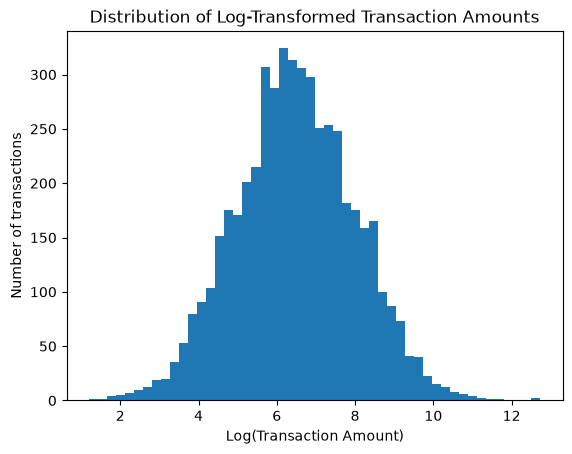

In [1942]:
plt.hist(df["log_amount"], bins=50)

plt.xlabel("Log(Transaction Amount)")
plt.ylabel("Number of transactions")
plt.title("Distribution of Log-Transformed Transaction Amounts")
plt.show()

### Calculating Z-Scores After the Log Transformation

Since the log transformation produces a more balanced distribution, we
can now calculate Z-scores using the log-transformed transaction amounts.

This allows us to test whether statistical outlier detection performs
better after accounting for the skewness of the original financial data.

In [1943]:
df["log_z_score"] = zscore(df["log_amount"])

df[["amount", "log_amount", "log_z_score"]].head(10)

,amount,log_amount,log_z_score
0,325.95,5.786744,-0.457588
1,409.19,6.014180,-0.307642
2,199.42,5.295413,-0.781520
3,4092.81,8.316987,1.210585
4,744.08,6.612149,0.086596
5,80.07,4.382901,-1.383133
6,499.72,6.214048,-0.175870
7,1994.09,7.597943,0.736524
8,1014.64,6.922289,0.291069
9,213.43,5.363309,-0.736756


### Applying the Z-Score Threshold to Log-Transformed Amounts

We use the same screening threshold as before: an absolute Z-score
greater than 3.

This allows us to make a fair comparison between the original Z-score
method and the log-transformed Z-score method.

In [1944]:
df["abs_log_z_score"] = df["log_z_score"].abs()

log_z_flags = df["abs_log_z_score"] > 3

print(f"Transactions flagged: {log_z_flags.sum()}")

Transactions flagged: 15


### Inspecting Log-Based Statistical Outliers

We now examine the transactions flagged by the log-based Z-score rule
and compare them with the known ground-truth labels.

This will show whether the log transformation helped the detector identify
the planted anomalies rather than simply reducing the number of extreme
transactions.

In [1945]:
log_z_candidates = df[log_z_flags].copy()

log_z_candidates[
    ["date", "vendor", "category", "amount", "log_z_score",
     "is_anomaly", "anomaly_type"]
].sort_values(
    "log_z_score",
    ascending=False
)

,date,vendor,category,amount,log_z_score,is_anomaly,anomaly_type
157,2025-01-13,V004,Travel,336671.21,4.117987,False,NaN
2149,2025-06-04,V020,Travel,278935.56,3.993957,False,NaN
3509,2025-09-13,V030,Utilities,115138.55,3.410585,False,NaN
744,2025-02-23,V020,Supplies,84985.89,3.210389,False,NaN
1300,2025-04-04,V012,Utilities,72349.18,3.104256,False,NaN
2335,2025-06-16,V045,Supplies,71328.86,3.094892,False,NaN
1032,2025-03-14,V019,Travel,65979.02,3.043490,False,NaN
4202,2025-11-02,V034,Maintenance,64086.46,3.024302,False,NaN
4952,2025-12-26,V009,Utilities,62614.84,3.008986,False,NaN
898,2025-03-05,V048,Consulting,6.53,-3.035649,False,NaN


In [1946]:
true_positives = (
    log_z_candidates["is_anomaly"] == True
).sum()

false_positives = (
    log_z_candidates["is_anomaly"] == False
).sum()

actual_anomalies = (
    df["is_anomaly"] == True
).sum()

false_negatives = actual_anomalies - true_positives

precision = true_positives / (true_positives + false_positives)
recall = true_positives / (true_positives + false_negatives)

print(f"True positives: {true_positives}")
print(f"False positives: {false_positives}")
print(f"False negatives: {false_negatives}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

True positives: 0
False positives: 15
False negatives: 130
Precision: 0.00%
Recall: 0.00%


### Interpretation of Log-Based Z-Score Detection

The log transformation substantially reduced the influence of extreme
transaction values and produced a more balanced distribution.

However, the log-based Z-score detector still failed to identify any of
the planted anomalies. It flagged 15 transactions, but all 15 were
legitimate transactions with unusually large or unusually small amounts.

This demonstrates that statistical extremeness alone is not sufficient
for detecting the types of anomalies present in this dataset.

The planted anomalies were designed around behavioural patterns, such as
round amounts, transactions just below an approval threshold, fabricated
amount patterns, and duplicate payments. These patterns do not
necessarily produce statistically extreme transaction amounts.

Therefore, the results suggest that combining statistical methods with
business-rule-based and pattern-based detection is more appropriate for
this type of financial anomaly analysis.

## 16. Benford-Based Transaction Analysis

Benford's Law can be used as a screening tool for financial data because
naturally occurring numerical data often follows a predictable
first-digit distribution.

Our earlier analysis tested Benford's Law across the entire dataset.

We now examine the first-digit distribution of different transaction
groups to determine whether the planted fabricated transactions show a
different pattern from legitimate transactions.

This is important because Benford's Law is more useful for identifying
patterns within groups of transactions than for declaring individual
transactions fraudulent based solely on their first digit.

In [1947]:
digit_by_type = pd.crosstab(
    df["anomaly_type"].replace("", "clean"),
    df["first_digit"],
    normalize="index"
)

digit_by_type

first_digit,1,2,3,4,5,6,7,8,9
anomaly_type,,,,,,,,,
below_threshold,0.000000,0.000000,0.000000,1.00,0.000000,0.000000,0.000000,0.000000,0.000000
duplicate,0.225000,0.250000,0.100000,0.15,0.075000,0.050000,0.050000,0.050000,0.050000
fabricated,0.033333,0.233333,0.066667,0.10,0.033333,0.166667,0.066667,0.233333,0.066667
round_number,0.300000,0.266667,0.233333,0.00,0.000000,0.000000,0.000000,0.200000,0.000000


### Vendor-Level Benford Analysis

Benford's Law is more useful when applied to groups of transactions
rather than individual transactions.

We therefore calculate the Mean Absolute Deviation (MAD) between each
vendor's observed first-digit distribution and the expected Benford
distribution.

A higher MAD indicates that the vendor's transaction amounts deviate
more strongly from the Benford distribution.

Vendors with unusually high deviations could therefore be prioritised
for further investigation.

In [1948]:
vendor_mad = {}

for vendor, group in df.groupby("vendor"):
    observed_vendor = (
        group["first_digit"]
        .value_counts(normalize=True)
        .reindex(digits, fill_value=0)
    )

    vendor_mad[vendor] = np.abs(
        observed_vendor.values - expected
    ).mean()

vendor_mad = pd.Series(vendor_mad).sort_values(ascending=False)

vendor_mad.head(10)

V007    0.034990
V027    0.034887
V030    0.034630
V013    0.031384
V014    0.031030
V032    0.029621
V021    0.029497
V031    0.029184
V009    0.029120
V045    0.028722
dtype: float64

### Comparing Benford Deviations with Known Anomalies

A high Benford deviation does not automatically indicate fraudulent
activity.

To evaluate whether vendor-level Benford screening is useful in this
synthetic dataset, we compare each vendor's Benford MAD with the number
of known planted anomalies associated with that vendor.

This allows us to see whether vendors with larger deviations also tend
to contain more anomalous transactions.

In [1949]:
vendor_anomalies = (
    df.groupby("vendor")["is_anomaly"]
    .sum()
    .sort_values(ascending=False)
)

vendor_summary = pd.DataFrame({
    "benford_mad": vendor_mad,
    "anomaly_count": vendor_anomalies
})

vendor_summary.sort_values(
    "benford_mad",
    ascending=False
).head(10)

,benford_mad,anomaly_count
V007,0.034990,1
V027,0.034887,3
V030,0.034630,4
V013,0.031384,1
V014,0.031030,1
V032,0.029621,3
V021,0.029497,5
V031,0.029184,5
V009,0.029120,2
V045,0.028722,3


### Measuring the Relationship

To quantify the relationship between Benford deviation and the number of
known anomalies, we calculate the correlation between vendor-level
Benford MAD and anomaly count.

A positive correlation would indicate that vendors with greater
deviations from Benford's Law tend to contain more planted anomalies.

However, correlation alone does not establish that Benford deviation
causes or proves anomalous activity.

In [1950]:
correlation = vendor_summary["benford_mad"].corr(
    vendor_summary["anomaly_count"]
)

print(f"Correlation: {correlation:.3f}")

Correlation: 0.028


### Benford's Law and Fabricated Transactions

The fabricated transactions were generated using approximately uniform
first digits rather than the naturally occurring Benford distribution.

We therefore compare their first-digit distribution with the clean
transactions to determine whether this planted anomaly type produces a
noticeable Benford pattern.

In [1951]:
fabricated_observed = (
    df[df["anomaly_type"] == "fabricated"]["first_digit"]
    .value_counts(normalize=True)
    .reindex(digits, fill_value=0)
)

clean_observed

first_digit
1    0.289002
2    0.164766
3    0.130754
4    0.105092
5    0.080652
6    0.068839
7    0.058656
8    0.054175
9    0.048065
Name: proportion, dtype: float64

In [1952]:
fabricated_observed

first_digit
1    0.033333
2    0.233333
3    0.066667
4    0.100000
5    0.033333
6    0.166667
7    0.066667
8    0.233333
9    0.066667
Name: proportion, dtype: float64

## 17. Combining Anomaly Detection Signals

The previous sections evaluated each anomaly-detection method
individually.

In practice, an auditor may consider several warning signs together
rather than relying on a single rule.

We therefore combine the individual detection signals into a single
table. Each signal is represented as either 1 (flagged) or 0 (not
flagged).

The combined signals can then be used to create an overall anomaly
score.

In [1953]:
df["round_flag"] = round_flags.astype(int)

df["threshold_flag"] = below_threshold_flags.astype(int)

df["duplicate_flag"] = duplicate_flags.astype(int)

df[
    ["amount", "round_flag", "threshold_flag", "duplicate_flag",
     "is_anomaly", "anomaly_type"]
].head(10)

,amount,round_flag,threshold_flag,duplicate_flag,is_anomaly,anomaly_type
0,325.95,0,0,0,False,NaN
1,409.19,0,0,0,False,NaN
2,199.42,0,0,0,False,NaN
3,4092.81,0,0,0,False,NaN
4,744.08,0,0,0,False,NaN
5,80.07,0,0,0,False,NaN
6,499.72,0,0,0,False,NaN
7,1994.09,0,0,0,False,NaN
8,1014.64,0,0,0,False,NaN
9,213.43,0,0,0,False,NaN


## 18. Creating an Anomaly Score

Each detection rule provides one warning signal.

We combine these signals by summing the individual flags. The resulting
anomaly score represents the number of detection rules that flagged a
transaction.

A higher score means that a transaction exhibits more suspicious
characteristics.

This score is not a probability of fraud. It is simply a prioritisation
tool for deciding which transactions may deserve further investigation.

In [1954]:
df["anomaly_score"] = (
    df["round_flag"]
    + df["threshold_flag"]
    + df["duplicate_flag"]
)

df[
    ["amount", "round_flag", "threshold_flag", "duplicate_flag",
     "anomaly_score", "is_anomaly", "anomaly_type"]
].sort_values(
    "anomaly_score",
    ascending=False
).head(20)

,amount,round_flag,threshold_flag,duplicate_flag,anomaly_score,is_anomaly,anomaly_type
2256,292.02,0,0,1,1,True,duplicate
2289,81.32,0,0,1,1,True,duplicate
2138,339.50,0,0,1,1,False,NaN
1685,4756.16,0,1,0,1,True,below_threshold
2374,312.45,0,0,1,1,True,duplicate
521,4927.67,0,1,0,1,False,NaN
445,4810.51,0,1,0,1,False,NaN
2042,4847.57,0,1,0,1,True,below_threshold
1803,3000.00,1,0,0,1,True,round_number
1767,4979.07,0,1,0,1,True,below_threshold


## 19. Distribution of Anomaly Scores

Before evaluating the anomaly score, we examine how many transactions
receive each possible score.

A score of 0 means that none of the three rules flagged the transaction.

A score of 1 means that one rule flagged it.

Higher scores indicate that multiple independent screening rules
identified the same transaction.

In [1955]:
score_counts = df["anomaly_score"].value_counts().sort_index()

score_counts

anomaly_score
0    4873
1     167
Name: count, dtype: int64

In [1956]:
print(
    f"Transactions with score >= 1: "
    f"{(df['anomaly_score'] >= 1).sum()}"
)

print(
    f"Transactions with score >= 2: "
    f"{(df['anomaly_score'] >= 2).sum()}"
)

Transactions with score >= 1: 167
Transactions with score >= 2: 0


### Evaluating the Combined Screening Rule

We treat any transaction with an anomaly score of at least 1 as a
candidate for investigation.

We then compare these candidates with the known ground-truth anomalies.

This allows us to measure whether combining the three screening rules
improves anomaly detection compared with the individual methods.

In [1957]:
combined_flags = df["anomaly_score"] >= 1

combined_candidates = df[combined_flags]

true_positives = (
    combined_candidates["is_anomaly"] == True
).sum()

false_positives = (
    combined_candidates["is_anomaly"] == False
).sum()

actual_anomalies = df["is_anomaly"].sum()

false_negatives = actual_anomalies - true_positives

precision = true_positives / (
    true_positives + false_positives
)

recall = true_positives / (
    true_positives + false_negatives
)

print(f"True positives: {true_positives}")
print(f"False positives: {false_positives}")
print(f"False negatives: {false_negatives}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

True positives: 100
False positives: 67
False negatives: 30
Precision: 59.88%
Recall: 76.92%


## 20. Adding a Benford-Based Signal

The previous analysis showed that the fabricated transactions had a
substantially different first-digit distribution from the clean
transactions.

We therefore introduce a simple Benford-based screening signal.

Transactions whose first digit is unusually common among the fabricated
group will receive a flag.

This is a deliberately simple signal for demonstrating how statistical
patterns can be incorporated into a combined anomaly-detection system.
It should not be interpreted as proof that an individual transaction is
fraudulent.

In [1958]:
benford_difference = (
    fabricated_observed - clean_observed
).abs()

benford_difference

first_digit
1    0.255669
2    0.068568
3    0.064087
4    0.005092
5    0.047318
6    0.097828
7    0.008011
8    0.179158
9    0.018601
Name: proportion, dtype: float64

In [1959]:
benford_difference.sort_values(ascending=False)

first_digit
1    0.255669
8    0.179158
6    0.097828
2    0.068568
3    0.064087
5    0.047318
9    0.018601
7    0.008011
4    0.005092
Name: proportion, dtype: float64

### Interpretation

The fabricated transactions showed substantial differences from the clean
transactions in their first-digit distribution, particularly for digits
1, 8, and 6.

However, these results were obtained from the same planted anomalies that
are used as the ground truth for evaluation. Using these observations to
construct a detection rule and then evaluating that rule on the same data
would introduce data leakage and could overstate the detector's
performance.

Therefore, the Benford comparison is retained as an exploratory analysis
rather than being incorporated into the final anomaly score.

This demonstrates an important principle in statistical modelling:
patterns identified from labelled data should not be evaluated on the
same observations used to discover those patterns.

In [1960]:
def evaluate(flags, actual):
    true_positives = (flags & actual).sum()
    false_positives = (flags & ~actual).sum()
    false_negatives = (~flags & actual).sum()

    precision = true_positives / (
        true_positives + false_positives
    ) if (true_positives + false_positives) > 0 else 0

    recall = true_positives / (
        true_positives + false_negatives
    ) if (true_positives + false_negatives) > 0 else 0

    return {
        "True Positives": true_positives,
        "False Positives": false_positives,
        "False Negatives": false_negatives,
        "Precision": precision,
        "Recall": recall
    }

In [1961]:
actual = df["is_anomaly"]

evaluate(round_flags, actual)

{'True Positives': np.int64(30),
 'False Positives': np.int64(0),
 'False Negatives': np.int64(100),
 'Precision': np.float64(1.0),
 'Recall': np.float64(0.23076923076923078)}

## 21. Evaluating Detection Methods

To evaluate the detection methods consistently, we define a reusable
evaluation function.

The function compares a set of detection flags against the known
ground-truth anomaly labels and calculates true positives, false
positives, false negatives, precision, and recall.

Recall is measured against all planted anomalies in the dataset so that
different detection methods can be compared on the same basis.

In [1962]:
evaluations = {
    "Round-number rule": evaluate(round_flags, actual),
    "Below-threshold rule": evaluate(below_threshold_flags, actual),
    "Duplicate detection": evaluate(duplicate_flags, actual),
    "Raw Z-score": evaluate(z_flags, actual),
    "Log Z-score": evaluate(log_z_flags, actual),
    "Combined rules": evaluate(combined_flags, actual)
}

evaluation_table = pd.DataFrame(evaluations).T

evaluation_table

,True Positives,False Positives,False Negatives,Precision,Recall
Round-number rule,30.0,0.0,100.0,1.000000,0.230769
Below-threshold rule,30.0,27.0,100.0,0.526316,0.230769
Duplicate detection,40.0,40.0,90.0,0.500000,0.307692
Raw Z-score,0.0,37.0,130.0,0.000000,0.000000
Log Z-score,0.0,15.0,130.0,0.000000,0.000000
Combined rules,100.0,67.0,30.0,0.598802,0.769231


## 22. Comparing Detection Methods

The different detection methods produced substantially different results.

We compare their precision and recall to evaluate how effectively each
method identified the planted anomalies.

Precision measures the proportion of flagged transactions that were
actually anomalous, while recall measures the proportion of all planted
anomalies that were successfully detected.

These metrics help identify which methods are most useful for screening
the synthetic financial ledger.

In [1963]:
results = evaluation_table.reset_index()
results = results.rename(columns={"index": "Method"})

results = results[["Method", "Precision", "Recall"]]

results

,Method,Precision,Recall
0,Round-number rule,1.000000,0.230769
1,Below-threshold rule,0.526316,0.230769
2,Duplicate detection,0.500000,0.307692
3,Raw Z-score,0.000000,0.000000
4,Log Z-score,0.000000,0.000000
5,Combined rules,0.598802,0.769231


## 23. Detection Performance Comparison

The following chart compares the precision and recall of the different
detection methods.

Precision measures the proportion of flagged transactions that were
actually anomalous, while recall measures the proportion of all 130
planted anomalies that were successfully detected.

Using the same recall denominator allows the individual rules to be
compared fairly with the combined detector.

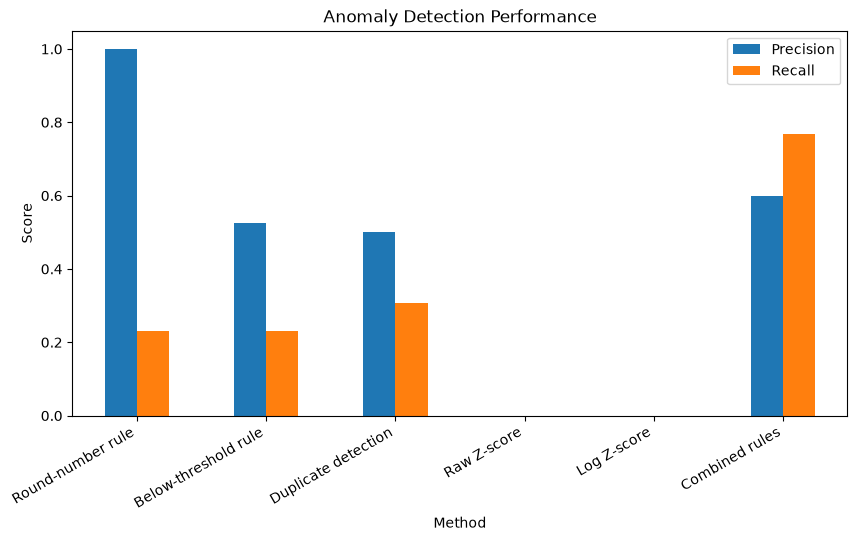

In [1964]:
results.plot(
    x="Method",
    y=["Precision", "Recall"],
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.title("Anomaly Detection Performance")
plt.legend()
plt.show()

## 24. Pair-Level Evaluation of Duplicate Detection

Row-level precision can be misleading for duplicate detection because
the detector flags both transactions in a potential duplicate pair.

A more appropriate evaluation is therefore performed at the pair level.

The synthetic dataset contains 40 planted duplicate transactions, each
created by copying a clean transaction. We evaluate whether the
duplicate detector successfully identifies all 40 corresponding pairs.

In [1965]:
# Identify the planted duplicate rows
planted_duplicates = df[df["anomaly_type"] == "duplicate"]

# Check whether each planted duplicate has a matching transaction
# with the same vendor, category, and amount.
duplicate_matches = planted_duplicates.merge(
    df[df["anomaly_type"] != "duplicate"],
    on=["vendor", "category", "amount"],
    how="inner",
    suffixes=("_duplicate", "_original")
)

pairs_found = len(duplicate_matches)

print(f"Planted duplicate pairs: {len(planted_duplicates)}")
print(f"Duplicate pairs detected: {pairs_found}")
print(f"Pair-level recall: {pairs_found / len(planted_duplicates):.2%}")

Planted duplicate pairs: 40
Duplicate pairs detected: 40
Pair-level recall: 100.00%


## 25. Benford Test on the Fabricated Transactions

The vendor-level analysis did not show a meaningful relationship between
Benford deviation and the number of planted anomalies.

However, the fabricated transactions can be examined as a separate
group. Because these transactions were deliberately generated with
approximately uniform first digits, we expect their distribution to
differ substantially from Benford's Law.

This illustrates an important property of Benford analysis: it can be
useful when suspicious transactions are concentrated within a group,
but its signal can become diluted when anomalies are spread across a
large dataset.

In [1966]:
fabricated_df = df[df["anomaly_type"] == "fabricated"]

fabricated_observed = (
    fabricated_df["first_digit"]
    .value_counts(normalize=True)
    .reindex(digits, fill_value=0)
)

fabricated_n = len(fabricated_df)

fabricated_chi2, fabricated_p = chisquare(
    fabricated_observed * fabricated_n,
    expected * fabricated_n
)

print(f"Fabricated transactions: {fabricated_n}")
print(f"Chi-square statistic: {fabricated_chi2:.2f}")
print(f"p-value: {fabricated_p:.5f}")

Fabricated transactions: 30
Chi-square statistic: 33.56
p-value: 0.00005


## 26. Conclusion

This project investigated whether statistical and rule-based methods
could be used to identify unusual transactions in a synthetic financial
ledger containing 130 known anomalies.

Benford's Law produced different results depending on how the data was
examined. The full dataset showed a statistically significant deviation
from Benford's distribution (p = 0.0100), while the clean transactions
did not show significant evidence of deviation (p = 0.1287). However,
vendor-level Benford deviation showed almost no relationship with the
number of planted anomalies, with a correlation of approximately 0.03.
This suggests that Benford analysis was not useful for identifying
suspicious vendors in this dataset.

When the fabricated transactions were isolated as a group, their
first-digit distribution showed a strong deviation from Benford's Law
(p ≈ 0.00005). This demonstrates that Benford analysis can be useful
when suspicious transactions are concentrated within a group, but its
signal may become diluted when anomalies are spread throughout a larger
dataset.

The rule-based methods were effective for the specific anomaly types
they were designed to detect. The round-number rule detected all 30
planted round-number anomalies, while the below-threshold rule detected
all 30 planted threshold anomalies. The duplicate detector identified
all 40 planted duplicate pairs. However, these rules also produced false
positives when evaluated at the transaction level, demonstrating that
business rules should be treated as screening mechanisms rather than
proof of wrongdoing.

The raw Z-score and log-transformed Z-score methods failed to detect any
of the planted anomalies. This demonstrated that statistical
extremeness does not necessarily indicate an anomalous financial
transaction. Legitimate financial data can be highly skewed, and
transforming the data does not automatically make generic outlier
detection effective for every type of financial anomaly.

When the three rule-based detectors were combined, they identified
100 of the 130 planted anomalies, giving a recall of 76.92% and a
precision of 59.88%. This provided substantially greater coverage than
any individual rule, although the combined detector still missed 30 anomalies. 
All 30 were fabricated transactions, which none of the three rules were designed to target.

An important limitation is that the detection rules were designed with
knowledge of how the synthetic anomalies were planted. Therefore, their
performance is partly circular and should not be interpreted as
representative of performance on real financial data. In particular,
the perfect performance of the round-number rule is partly an artefact
of the synthetic dataset, where round-number transactions were
deliberately created as anomalies. Real financial records may contain
many legitimate round amounts, such as rent, salaries, subscriptions,
and fixed fees.

Overall, the results demonstrate that financial anomaly detection is
better approached as a combination of statistical analysis,
business-specific rules, and contextual investigation. Automated
methods can help auditors prioritise transactions for further review,
but they should not be treated as automatic evidence of fraud.

Future work could test the methods on real or more realistically
simulated financial data, introduce less predictable anomaly patterns,
and develop more robust statistical or machine-learning approaches
without using the planted anomaly labels to construct the detection
rules.

## Methodological Improvement: Separate Development and Test Data

The initial experiment evaluated detection rules on the same synthetic dataset used to design those rules. Because the planted anomalies were deliberately constructed, this may overstate how well the methods generalise to other financial data.

To improve the experimental design, a separate test dataset will be used to evaluate detection performance. Related transactions, including original and duplicate payment records, must remain in the same partition to prevent information leakage.

The test results will be treated as an evaluation of performance on unseen synthetic transactions, rather than evidence of effectiveness on real financial records.


In [1967]:
# Create a unique ID for transactions with the same vendor,
# category, and amount.
df["transaction_group"] = (
    df.groupby(["vendor", "category", "amount"]).ngroup()
)

df[[
    "vendor",
    "category",
    "amount",
    "anomaly_type",
    "transaction_group"
]].head(10)

,vendor,category,amount,anomaly_type,transaction_group
0,V008,Supplies,325.95,NaN,733
1,V027,Maintenance,409.19,NaN,2676
2,V032,Travel,199.42,NaN,3221
3,V045,Maintenance,4092.81,NaN,4483
4,V038,Consulting,744.08,NaN,3767
5,V019,Supplies,80.07,NaN,1883
6,V015,Consulting,499.72,NaN,1430
7,V021,Supplies,1994.09,NaN,2057
8,V001,Supplies,1014.64,NaN,51
9,V001,Maintenance,213.43,NaN,27


In [1968]:
# Count how many transactions belong to each group
group_sizes = df["transaction_group"].value_counts()

print("Total transaction groups:", group_sizes.size)
print("Groups containing multiple transactions:", (group_sizes > 1).sum())
print("Largest group size:", group_sizes.max())

# Inspect groups containing planted duplicate transactions
df[df["anomaly_type"] == "duplicate"][
    ["vendor", "category", "amount", "date", "transaction_group"]
].head(10)

Total transaction groups: 5000
Groups containing multiple transactions: 40
Largest group size: 2


,vendor,category,amount,date,transaction_group
182,V033,Supplies,524.14,2025-01-15,3302
198,V001,Travel,701.38,2025-01-16,67
214,V036,Supplies,9219.38,2025-01-17,3625
358,V050,Maintenance,45.02,2025-01-28,4910
376,V028,Travel,465.12,2025-01-29,2824
476,V027,Consulting,1292.79,2025-02-05,2660
613,V001,Utilities,610.26,2025-02-14,89
826,V005,Maintenance,122.19,2025-02-28,424
1022,V015,Maintenance,678.65,2025-03-14,1461
1353,V039,Maintenance,5691.33,2025-04-08,3902


In [1969]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

development_idx, test_idx = next(
    splitter.split(df, groups=df["transaction_group"])
)

development_df = df.iloc[development_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Development rows:", len(development_df))
print("Test rows:", len(test_df))
print("Total rows:", len(development_df) + len(test_df))

Development rows: 4035
Test rows: 1005
Total rows: 5040


In [1970]:
development_groups = set(development_df["transaction_group"])
test_groups = set(test_df["transaction_group"])

overlapping_groups = development_groups & test_groups

print("Groups in both partitions:", len(overlapping_groups))
print("Development groups:", len(development_groups))
print("Test groups:", len(test_groups))

Groups in both partitions: 0
Development groups: 4000
Test groups: 1000


In [1971]:
print("Development anomaly counts:")
print(
    development_df["anomaly_type"]
    .fillna("clean")
    .replace("", "clean")
    .value_counts()
)

print("\nTest anomaly counts:")
print(
    test_df["anomaly_type"]
    .fillna("clean")
    .replace("", "clean")
    .value_counts()
)

Development anomaly counts:
anomaly_type
clean              3928
duplicate            35
round_number         26
fabricated           25
below_threshold      21
Name: count, dtype: int64

Test anomaly counts:
anomaly_type
clean              982
below_threshold      9
duplicate            5
fabricated           5
round_number         4
Name: count, dtype: int64


In [1972]:
test_actual = test_df["is_anomaly"]

test_evaluations = {
    "Round-number rule": evaluate(
        round_flags.loc[test_df.index], test_actual
    ),
    "Below-threshold rule": evaluate(
        below_threshold_flags.loc[test_df.index], test_actual
    ),
    "Duplicate detection": evaluate(
        duplicate_flags.loc[test_df.index], test_actual
    ),
    "Combined rules": evaluate(
        combined_flags.loc[test_df.index], test_actual
    )
}

test_evaluation_table = pd.DataFrame(test_evaluations).T
test_evaluation_table

,True Positives,False Positives,False Negatives,Precision,Recall
Round-number rule,4.0,0.0,19.0,1.000000,0.173913
Below-threshold rule,9.0,5.0,14.0,0.642857,0.391304
Duplicate detection,5.0,5.0,18.0,0.500000,0.217391
Combined rules,18.0,10.0,5.0,0.642857,0.782609


### Interpretation of the Held-Out Test Results

The grouped test split contained 1,005 transactions, including 23 planted anomalies. The combined rule-based detector identified 18 of these anomalies, achieving a recall of 78.26% and a precision of 64.29%.

The combined detector achieved higher recall than any individual rule in this test set, although 10 clean transactions were also flagged. This illustrates the trade-off between detecting more suspicious transactions and generating additional false positives.

These results should be interpreted cautiously because the test set contains relatively few anomalies and the detection rules were designed with knowledge of the synthetic anomaly types. Repeated grouped evaluations will be used to assess how sensitive the results are to the choice of split.


## Repeated Evaluation Across Different Splits

A single train-test split can produce results that depend on which transactions are assigned to the test set.

To investigate this, the grouped train-test split will be repeated using different random seeds. Transaction groups will remain intact in every split, preventing matching transactions from being separated between development and test data.

The same detection rules will be evaluated in each repetition. Their precision and recall will then be compared to assess the stability of the results.

This is a sensitivity analysis of the current synthetic dataset, not a substitute for evaluation on independent real-world financial records.


In [1973]:
from sklearn.model_selection import GroupShuffleSplit

rules = {
    "Round-number rule": round_flags,
    "Below-threshold rule": below_threshold_flags,
    "Duplicate detection": duplicate_flags,
    "Combined rules": combined_flags
}

repeated_results = []

for seed in range(5):
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=seed
    )

    development_idx, test_idx = next(
        splitter.split(df, groups=df["transaction_group"])
    )

    test_actual = df["is_anomaly"].iloc[test_idx]

    for method, flags in rules.items():
        test_flags = flags.iloc[test_idx]

        metrics = evaluate(test_flags, test_actual)

        repeated_results.append({
            "Seed": seed,
            "Method": method,
            "Test anomalies": int(test_actual.sum()),
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"]
        })

repeated_results_df = pd.DataFrame(repeated_results)

repeated_results_df

,Seed,Method,Test anomalies,Precision,Recall
0,0,Round-number rule,27,1.000000,0.259259
1,0,Below-threshold rule,27,0.428571,0.111111
2,0,Duplicate detection,27,0.500000,0.370370
3,0,Combined rules,27,0.588235,0.740741
4,1,Round-number rule,21,1.000000,0.190476
5,1,Below-threshold rule,21,0.500000,0.238095
6,1,Duplicate detection,21,0.500000,0.333333
7,1,Combined rules,21,0.571429,0.761905
8,2,Round-number rule,24,1.000000,0.291667
9,2,Below-threshold rule,24,0.545455,0.250000


In [1974]:
repeated_summary = (
    repeated_results_df
    .groupby("Method")
    .agg(
        Mean_Precision=("Precision", "mean"),
        SD_Precision=("Precision", "std"),
        Mean_Recall=("Recall", "mean"),
        SD_Recall=("Recall", "std")
    )
)

repeated_summary.round(3)

,Mean_Precision,SD_Precision,Mean_Recall,SD_Recall
Method,,,,
Below-threshold rule,0.495,0.053,0.198,0.060
Combined rules,0.583,0.036,0.791,0.056
Duplicate detection,0.500,0.000,0.372,0.089
Round-number rule,1.000,0.000,0.220,0.063


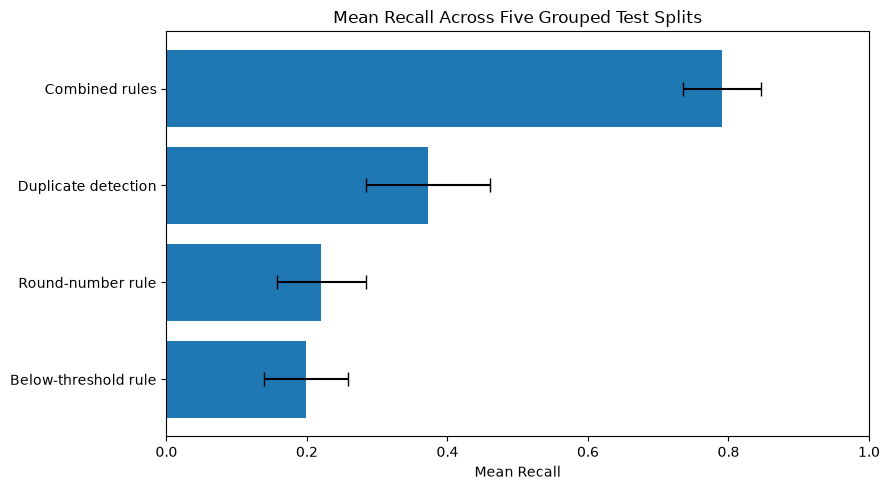

In [1975]:
recall_summary = repeated_summary.sort_values("Mean_Recall")

plt.figure(figsize=(9, 5))

plt.barh(
    recall_summary.index,
    recall_summary["Mean_Recall"],
    xerr=recall_summary["SD_Recall"],
    capsize=5
)

plt.xlabel("Mean Recall")
plt.xlim(0, 1)
plt.title("Mean Recall Across Five Grouped Test Splits")
plt.tight_layout()
plt.show()

### Interpretation of Repeated Evaluation

The combined rule-based detector achieved the highest mean recall across the five grouped test splits, at 79.1%, with a standard deviation of 5.6 percentage points. Its mean precision was 58.3%, indicating that a substantial proportion of flagged transactions were clean transactions.

The round-number rule achieved 100% mean precision but only 22.0% mean recall. This reflects its narrow focus on one particular anomaly type in the synthetic dataset. The duplicate detector achieved 37.2% mean recall, but its row-level precision of 50.0% reflects the fact that both the original and duplicate records are flagged.

Repeating the grouped split showed that the combined detector's recall was relatively consistent across these five experiments. However, the experiments reused the same synthetic dataset, and the detection rules were designed with knowledge of the planted anomaly types. These findings therefore measure sensitivity to the train-test split rather than generalisation to independent financial datasets.

The results support using multiple detection rules to broaden screening coverage, while treating flagged transactions as candidates for further investigation rather than proof of fraud.


## Independent Synthetic Test Dataset

Repeatedly splitting the original dataset helps assess sensitivity to the choice of test split, but all repetitions still use the same underlying transactions.

To assess performance on new synthetic data, an independent ledger will be generated using a different random seed. The existing detection rules will be applied without changing their definitions.

This experiment provides a stronger test of whether the rules identify the anomaly patterns they were designed to detect in newly generated transactions. However, because the new dataset uses the same generator and anomaly-generation mechanisms, it does not establish generalisation to real financial records or previously unseen types of anomalies.


In [1976]:
from src.generate_ledger import generate_ledger

independent_df = generate_ledger(seed=123)
independent_df.shape

(5040, 6)

In [1977]:

# Apply the existing detection rules without changing their definitions.

independent_df["round_flag"] = (
    independent_df["amount"] % 1000 == 0
)

approval_limit = 5000

independent_df["threshold_flag"] = (
    (independent_df["amount"] >= 0.95 * approval_limit) &
    (independent_df["amount"] < approval_limit)
)

independent_df["duplicate_flag"] = independent_df.duplicated(
    subset=["vendor", "category", "amount"],
    keep=False
)

independent_df["anomaly_score"] = (
    independent_df["round_flag"].astype(int)
    + independent_df["threshold_flag"].astype(int)
    + independent_df["duplicate_flag"].astype(int)
)

independent_df["combined_flag"] = (
    independent_df["anomaly_score"] >= 1
)

print("Independent ledger rows:", len(independent_df))
print("Actual anomalies:", independent_df["is_anomaly"].sum())
print("Combined rule flags:", independent_df["combined_flag"].sum())

Independent ledger rows: 5040
Actual anomalies: 130
Combined rule flags: 174


In [1978]:

independent_evaluation = {}

for method, flag_column in {
    "Round-number rule": "round_flag",
    "Below-threshold rule": "threshold_flag",
    "Duplicate detection": "duplicate_flag",
    "Combined rules": "combined_flag"
}.items():

    independent_evaluation[method] = evaluate(
        independent_df[flag_column],
        independent_df["is_anomaly"]
    )

independent_evaluation_table = (
    pd.DataFrame(independent_evaluation).T
)

independent_evaluation_table.round(3)

,True Positives,False Positives,False Negatives,Precision,Recall
Round-number rule,30.0,0.0,100.0,1.000,0.231
Below-threshold rule,30.0,30.0,100.0,0.500,0.231
Duplicate detection,40.0,44.0,90.0,0.476,0.308
Combined rules,100.0,74.0,30.0,0.575,0.769


### Evaluation on an Independent Synthetic Ledger

The combined rule-based detector identified 100 of the 130 planted anomalies in a newly generated synthetic ledger, achieving 76.92% recall and 57.47% precision. These results were broadly consistent with the original dataset, where recall was 76.92% and precision was 59.88%.

The combined detector therefore showed similar performance across two independently sampled ledgers generated using the same procedure. However, it flagged 74 clean transactions in the independent ledger, illustrating the need to review flagged records rather than assume they represent fraud.

Duplicate detection also produced 44 false positives, compared with 40 in the original experiment. This illustrates how matching vendor, category, and amount values can flag legitimate transactions as potential duplicates.

These findings demonstrate reproducibility across different random samples from the same synthetic generator. They do not establish performance on real financial records, where transaction patterns and anomalous behaviour may differ.


In [1979]:

# Select planted anomalies that the combined detector missed.
missed_anomalies = independent_df[
    independent_df["is_anomaly"] &
    ~independent_df["combined_flag"]
]

# Count missed anomalies by type.
missed_by_type = (
    missed_anomalies["anomaly_type"]
    .value_counts()
    .rename_axis("Anomaly Type")
    .reset_index(name="Missed Count")
)

# Count all planted anomalies by type.
total_by_type = (
    independent_df[independent_df["is_anomaly"]]["anomaly_type"]
    .value_counts()
    .rename_axis("Anomaly Type")
    .reset_index(name="Total Anomalies")
)

# Combine the counts and calculate the miss rate.
miss_analysis = total_by_type.merge(
    missed_by_type,
    on="Anomaly Type",
    how="left"
)

miss_analysis["Missed Count"] = (
    miss_analysis["Missed Count"].fillna(0).astype(int)
)

miss_analysis["Miss Rate"] = (
    miss_analysis["Missed Count"] /
    miss_analysis["Total Anomalies"]
)

miss_analysis.sort_values(
    "Miss Rate", ascending=False
).round(3)

,Anomaly Type,Total Anomalies,Missed Count,Miss Rate
1,fabricated,30,30,1.0
0,duplicate,40,0,0.0
2,below_threshold,30,0,0.0
3,round_number,30,0,0.0


### Analysis of Missed Anomalies by Type

The combined detector missed all 30 planted fabricated transactions in the independent synthetic ledger, resulting in a 100% miss rate for this category. In contrast, it detected all planted round-number, below-threshold, and duplicate anomalies in this experiment.

This result reflects the design of the detector: its three rules target specific transaction patterns, whereas fabricated transactions can have ordinary-looking amounts and may not trigger any of these rules. The finding demonstrates that combining several rules does not guarantee coverage of every anomaly type.

The results also reflect the controlled design of the synthetic dataset. The perfect detection rates for the other three categories should not be interpreted as evidence that the rules would achieve perfect detection on real financial records.

A potential improvement is to investigate additional statistical screening methods for unusual transaction amounts, while evaluating whether they detect fabricated transactions without generating excessive false positives.


In [1980]:

# Extract the first significant digit from each transaction amount.
def first_significant_digit(amount):
    return int(str(float(amount)).replace(".", "").lstrip("0")[0])

independent_df["first_digit"] = (
    independent_df["amount"].apply(first_significant_digit)
)

# Benford's expected first-digit probabilities.
digits = np.arange(1, 10)

benford_probabilities = np.log10(1 + 1 / digits)

benford_distribution = pd.DataFrame({
    "First Digit": digits,
    "Expected Proportion": benford_probabilities
})

benford_distribution

,First Digit,Expected Proportion
0,1,0.301030
1,2,0.176091
2,3,0.124939
3,4,0.096910
4,5,0.079181
5,6,0.066947
6,7,0.057992
7,8,0.051153
8,9,0.045757


In [1981]:

observed_counts = (
    independent_df["first_digit"]
    .value_counts()
    .reindex(digits, fill_value=0)
    .sort_index()
)

benford_comparison = benford_distribution.copy()

benford_comparison["Observed Count"] = observed_counts.values
benford_comparison["Observed Proportion"] = (
    observed_counts.values / len(independent_df)
)

benford_comparison["Difference"] = (
    benford_comparison["Observed Proportion"]
    - benford_comparison["Expected Proportion"]
)

benford_comparison.round(4)

,First Digit,Expected Proportion,Observed Count,Observed Proportion,Difference
0,1,0.3010,1474,0.2925,-0.0086
1,2,0.1761,850,0.1687,-0.0074
2,3,0.1249,598,0.1187,-0.0063
3,4,0.0969,505,0.1002,0.0033
4,5,0.0792,419,0.0831,0.0040
5,6,0.0669,345,0.0685,0.0015
6,7,0.0580,287,0.0569,-0.0010
7,8,0.0512,295,0.0585,0.0074
8,9,0.0458,267,0.0530,0.0072


In [1982]:

from scipy.stats import chisquare

observed = benford_comparison["Observed Count"].to_numpy()

expected = (
    benford_comparison["Expected Proportion"].to_numpy()
    * len(independent_df)
)

chi_stat, p_value = chisquare(
    f_obs=observed,
    f_exp=expected
)

mad = np.mean(
    np.abs(
        benford_comparison["Observed Proportion"]
        - benford_comparison["Expected Proportion"]
    )
)

print(f"Chi-square statistic: {chi_stat:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"MAD: {mad:.4f}")

Chi-square statistic: 17.337
P-value: 0.0268
MAD: 0.0052


### Benford's Law Analysis of the Independent Ledger

The independent synthetic ledger produced a first-digit chi-square statistic of 17.337 with a p-value of 0.0268. At the 5% significance level, this provides evidence that the observed first-digit distribution differs from the distribution expected under Benford's Law.

The Mean Absolute Deviation (MAD) was 0.0052, indicating an average absolute difference of approximately 0.52 percentage points between observed and expected digit proportions. Although the chi-square test indicated a statistically significant difference, the magnitude of the deviations was relatively modest.

This result illustrates why statistical significance should be considered alongside practical effect size. A deviation from Benford's Law is a screening signal, not proof of fraud. Its usefulness also depends on whether the financial data are suitable for Benford analysis, and the synthetic ledger cannot establish how the method would perform on real company records.


In [1983]:

# Select clean and fabricated transactions for comparison.
clean_df = independent_df[
    ~independent_df["is_anomaly"]
]

fabricated_df = independent_df[
    independent_df["anomaly_type"] == "fabricated"
]

# Calculate observed first-digit proportions for each group.
clean_digit_proportions = (
    clean_df["first_digit"]
    .value_counts(normalize=True)
    .reindex(digits, fill_value=0)
)

fabricated_digit_proportions = (
    fabricated_df["first_digit"]
    .value_counts(normalize=True)
    .reindex(digits, fill_value=0)
)

digit_group_comparison = pd.DataFrame({
    "First Digit": digits,
    "Benford Expected": benford_probabilities,
    "Clean Transactions": clean_digit_proportions.values,
    "Fabricated Transactions": fabricated_digit_proportions.values
})

digit_group_comparison.round(3)

,First Digit,Benford Expected,Clean Transactions,Fabricated Transactions
0,1,0.301,0.295,0.067
1,2,0.176,0.171,0.000
2,3,0.125,0.119,0.133
3,4,0.097,0.095,0.133
4,5,0.079,0.084,0.167
5,6,0.067,0.070,0.033
6,7,0.058,0.057,0.167
7,8,0.051,0.057,0.233
8,9,0.046,0.053,0.067


In [1984]:

from scipy.stats import chisquare

def benford_metrics(amounts):
    first_digits = amounts.apply(first_significant_digit)

    observed = (
        first_digits.value_counts()
        .reindex(digits, fill_value=0)
        .to_numpy()
    )

    expected = len(amounts) * benford_probabilities

    chi_stat, p_value = chisquare(
        f_obs=observed,
        f_exp=expected
    )

    observed_proportions = observed / len(amounts)

    mad = np.mean(
        np.abs(observed_proportions - benford_probabilities)
    )

    return {
        "Sample Size": len(amounts),
        "Chi-square": chi_stat,
        "P-value": p_value,
        "MAD": mad
    }


group_benford_results = pd.DataFrame({
    "Clean": benford_metrics(clean_df["amount"]),
    "Fabricated": benford_metrics(fabricated_df["amount"])
}).T

group_benford_results.round(4)

,Sample Size,Chi-square,P-value,MAD
Clean,4910.0,13.7183,0.0894,0.0045
Fabricated,30.0,40.4517,0.0000,0.0987


### Benford's Law: Clean vs Fabricated Transactions

The clean subset contained 4,910 transactions and had a first-digit MAD of 0.0045. Its chi-square goodness-of-fit test produced a p-value of 0.0894, so the null hypothesis of conformity to Benford's distribution was not rejected at the 5% significance level.

The fabricated subset contained 30 transactions and had a much larger MAD of 0.0987, indicating a substantial difference from Benford's expected first-digit distribution. Its chi-square statistic was 40.452. However, the sample was small, and the expected count for each digit was below five; therefore, the usual chi-square approximation may not be reliable for this subset.

The contrast demonstrates that Benford's Law can help identify group-level digit-pattern deviations in this particular synthetic dataset. However, the fabricated amounts were generated using a roughly uniform first-digit mechanism, so the result reflects the assumptions built into the simulation. It does not establish that Benford's Law can reliably detect real-world fraud or classify individual transactions.

Benford analysis should therefore be treated as an additional screening signal that may guide further investigation, rather than as standalone evidence of fraudulent activity.


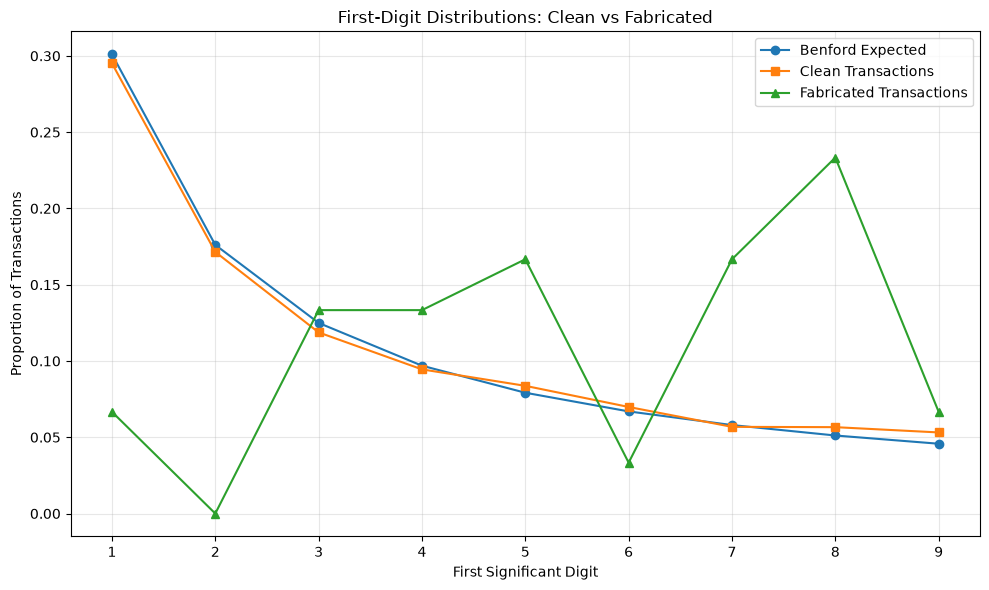

In [1985]:

plt.figure(figsize=(10, 6))

plt.plot(
    digits,
    benford_probabilities,
    marker="o",
    label="Benford Expected"
)

plt.plot(
    digits,
    clean_digit_proportions.values,
    marker="s",
    label="Clean Transactions"
)

plt.plot(
    digits,
    fabricated_digit_proportions.values,
    marker="^",
    label="Fabricated Transactions"
)

plt.xticks(digits)
plt.xlabel("First Significant Digit")
plt.ylabel("Proportion of Transactions")
plt.title("First-Digit Distributions: Clean vs Fabricated")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Visual Comparison of First-Digit Distributions

The chart compares Benford's expected first-digit proportions with those observed in clean and fabricated transactions. The clean transaction distribution broadly follows the expected declining pattern, while the fabricated subset exhibits larger deviations, particularly for digits 1, 2, 5, 7, and 8.

This visual comparison supports the earlier MAD analysis, which found a much larger deviation for fabricated transactions (0.0987) than for clean transactions (0.0045).

The fabricated subset contains only 30 records, so its observed proportions are sensitive to individual transactions. Furthermore, the generator deliberately assigns fabricated amounts using a roughly uniform first-digit mechanism. The chart therefore illustrates how Benford's Law can reveal a designed distributional difference, rather than demonstrating reliable detection of real-world fraud.


In [1986]:

# Summarise the independent-ledger rule evaluation.
final_rule_summary = independent_evaluation_table[
    ["True Positives", "False Positives", "False Negatives",
     "Precision", "Recall"]
].copy()

final_rule_summary[
    ["Precision", "Recall"]
] *= 100

final_rule_summary = final_rule_summary.rename(columns={
    "True Positives": "True Positives",
    "False Positives": "False Positives",
    "False Negatives": "False Negatives",
    "Precision": "Precision (%)",
    "Recall": "Recall (%)"
})

final_rule_summary.round(2)

,True Positives,False Positives,False Negatives,Precision (%),Recall (%)
Round-number rule,30.0,0.0,100.0,100.00,23.08
Below-threshold rule,30.0,30.0,100.0,50.00,23.08
Duplicate detection,40.0,44.0,90.0,47.62,30.77
Combined rules,100.0,74.0,30.0,57.47,76.92
